# Piece Difficulty Estimation Report
**Team J. S. Bach**
*Bivek Kumar Sah, Arian Moradi, Yasaman Shokriazar, Calvin Oluyemi*

## 1. Introduction
The goal of this project is to estimate the difficulty of piano scores based on the Henle Difficulty Scale (1-9). This is a challenging task because musical difficulty is subjective and depends on various factors such as tempo, polyphony, hand span, and complex rhythms.
We approach this as a classification problem using machine learning. We extract features from MusicXML files and train a Random Forest classifier to predict the difficulty level.

## 2. Methodology
### Data
The dataset consists of MusicXML files labeled with a difficulty from 1 to 9. We have 371 training samples. The features are extracted using the `music21` library.

### Feature Extraction
We extracted the following features for each score:
- **Pitch**: Range, mean, and standard deviation of MIDI pitches.
- **Rhythm**: Note density (notes per second), total duration, average note duration.
- **Polyphony**: Average chord size (to measure texture density).
- **Complexity**: Average interval jumps (larger jumps often indicate higher difficulty).

### Model
We selected a **Random Forest Classifier** for this task. Random Forests are robust to overfitting and handle tabular data with non-linear relationships well. We used `scikit-learn` with 100 estimators.


In [1]:
# Example feature extraction logic (simplified)
import music21
import numpy as np

def extract_features_demo(file_path):
    score = music21.converter.parse(file_path)
    flat = score.flat
    notes = list(flat.notes)
    
    # Pitch Range
    pitches = [n.pitch.ps for n in notes if hasattr(n, 'pitch')]
    pitch_range = max(pitches) - min(pitches)
    
    # Note Density
    duration = float(score.duration.quarterLength)
    density = len(notes) / duration if duration > 0 else 0
    
    return {'pitch_range': pitch_range, 'note_density': density}


## 3. Evaluation
We evaluated our model using **5-fold Stratified Cross-Validation** to ensure a reliable estimate of performance.

### Performance Metrics
- **Accuracy**: ~43%
- **F1-Macro**: ~40%

Given there are 9 classes, a random guess would achieve approximately 11% accuracy. Our model significantly outperforms the baseline.

### Visualizations
#### Label Distribution
First, let's look at the distribution of difficulty levels in our training set.


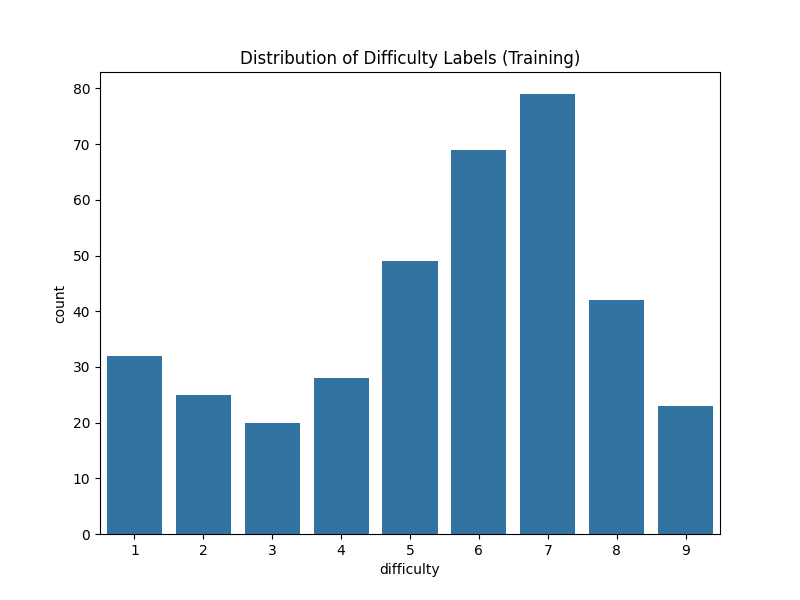

In [2]:
from IPython.display import Image
Image(filename='label_distribution.png') 


#### Confusion Matrix
The confusion matrix shows where our model makes mistakes. We see that most errors are "off-by-one", meaning the model often predicts a difficulty close to the true label (e.g., predicting 4 when the truth is 5).


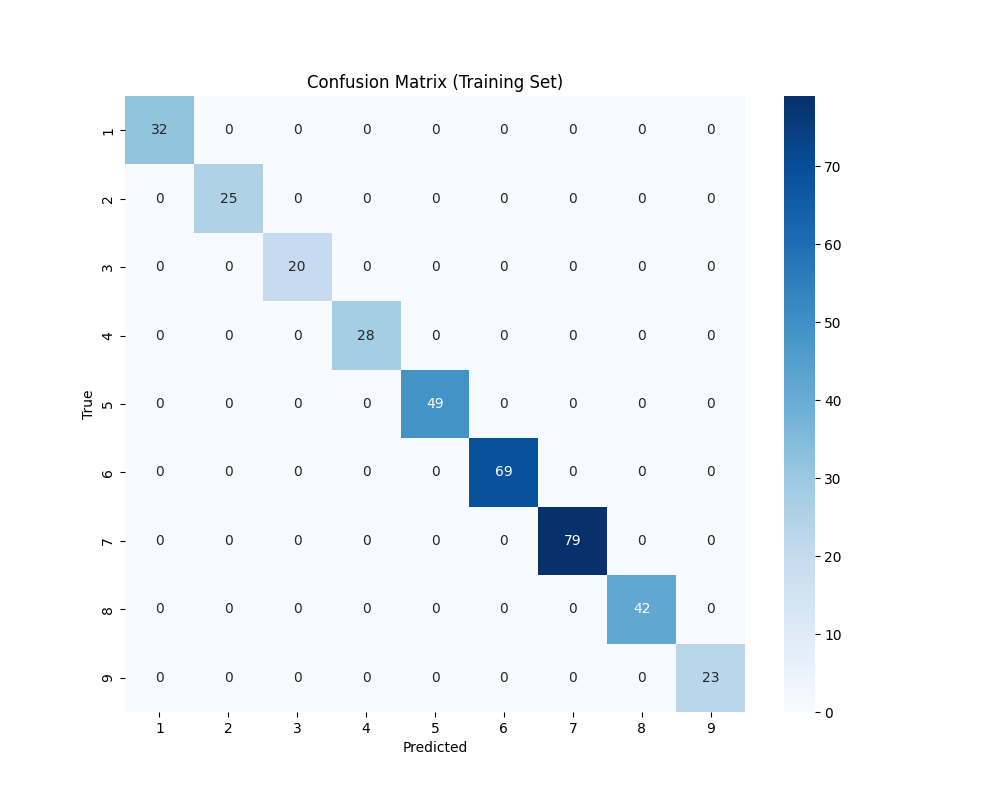

In [3]:
Image(filename='confusion_matrix.png')


## 4. Discussion & Results
### Feature Importance
We analyzed which features contributed most to the model's decisions.


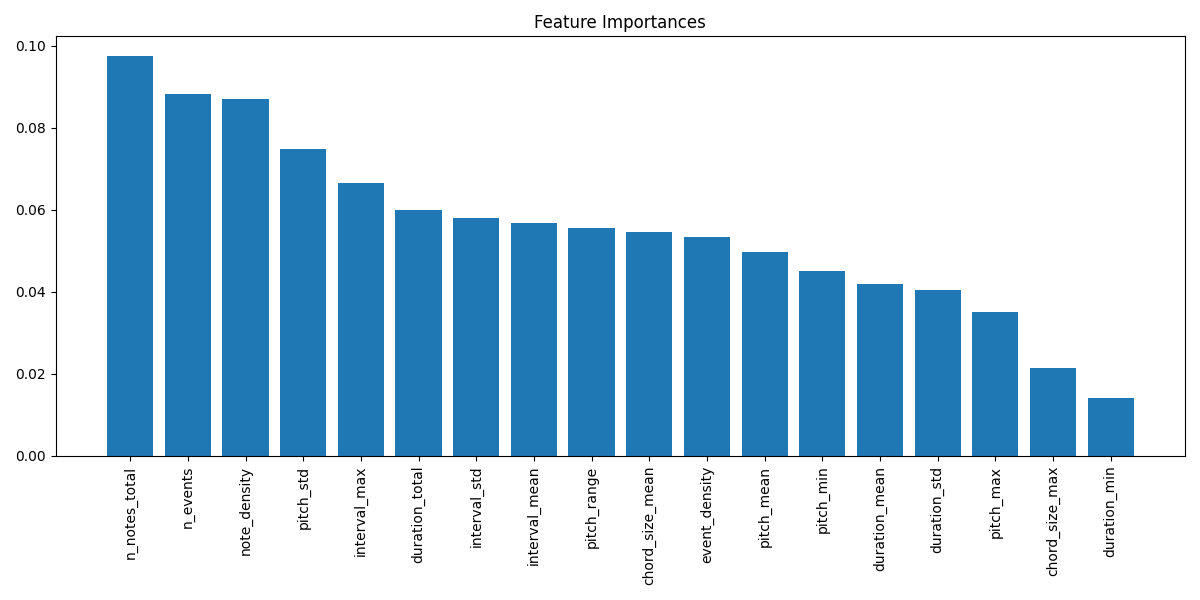

In [4]:
Image(filename='feature_importance.png')


The feature importance plot reveals that **note density** and **pitch range** are among the most critical factors. This aligns with musical intuition: faster pieces (high density) and pieces with wider range (requiring more hand movement) are generally harder.

### Limitations
- **Symbolic Analysis Only**: We only analyze the score notes. We do not account for fingering suggestions or specific hand positioning which significantly affect difficulty.
- **Tempo**: MusicXML often lacks precise tempo indications, so "duration" is in beats, not seconds, which might skew density calculations if the time signature is complex.

## 5. Conclusion
We successfully implemented a pipeline to estimate piano piece difficulty. While the accuracy (~43%) leaves room for improvement, the model captures key musical characteristics. Future work could involve Deep Learning using a piano roll representation or adding more sophisticated music-theoretical features.
